# Beyond BLAST

In [1]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 

using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON;

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   2158.1 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-2526-539a-8948-aa9e7f6db7cd is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    566.2 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

In [169]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
using .shear_shear

┌ Warning: Replacing docs for `Main.Blast.get_clencurt_grid_z :: Tuple{Number, Number, Number}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243
┌ Warning: Replacing docs for `Main.Blast.get_clencurt_weights_z :: Tuple{Number, Number, Number}` in module `Main.Blast`
└ @ Base.Docs docs/Docs.jl:243


In [215]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
Sl_plots = joinpath(plot_subdir, "Sl_plots")
Kernel_plots = joinpath(plot_subdir, "kernels")
quantity_subdir = joinpath(output_dir, "quantities")
chebcoefs = joinpath(quantity_subdir, "chebcoefs")
Sl = joinpath(quantity_subdir, "Sl")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
mkpath(chebcoefs)
mkpath(Sl)
mkpath(Sl_plots)
mkpath(Kernel_plots)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_06_30_190005, out/runs/run_2026_06_30_190005/plots and out/runs/run_2026_06_30_190005/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [216]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
x_b = npzread("blast_code/data/background/chi.npy") # array
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz") # array
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, x_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(x_b, z_b); # χ(z)

#### Setting parameters

In [217]:
cosmo = Blast.FlatΛCDM()
N = 2^15+1
n_chi = N                                             # Number of comoving distance points
x = LinRange(26, 7000, n_chi)                         # in Mpc/h: from 26 Mpc/h to 7000 Mpc/h
z = z_of_χ.(x)
ℓ = LinRange(2, 200, 100)
x_min = minimum(x)                                    # minimum comoving distance [Mpc/h]
x_max = maximum(x)                                    # maximum comoving distance [Mpc/h]
z_n5k = n5k_bins["z_cl"]
zmin = minimum(z_n5k)                                 # minimum redshift
zmax = maximum(z_n5k)                                 # maximum redshift
kmax = 200/13                                         # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/x_max                                      # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 120                                          # number of Chebyshev nodes 
Nz = n_chi
Nk = 150 #Nk = Nz
Nkp = 50
Nkpp = 50
k_grid = sort(Blast.get_clencurt_grid(kmin, kmax, Nk))
kp_grid = sort(Blast.get_clencurt_grid(kmin, kmax, Nkp))
kpp_grid = sort(Blast.get_clencurt_grid(kmin, kmax, Nkpp))
;

In [218]:
params_run = Dict(
    "x_min" => x_min,
    "x_max" => x_max,
    "n_chi" => n_chi,
    "zmin" => zmin,
    "zmax" => zmax,
    "kmin" => kmin,
    "kmax" => kmax,
    "n_cheb" => n_cheb,
    "N" => N,
    "ℓ" => length(ℓ)
)

open(joinpath(output_dir, "config.json"), "w") do dictio
    JSON.print(dictio, params_run, 4)
end

println("Data brought to safety in folder: ", output_dir)

Data brought to safety in folder: out/runs/run_2026_06_30_190005


In [219]:
#shear_prefac_W = shear_shear.shear_prefactor(x, z, cosmo; output_dir=output_dir);
#shear_prefac_W_cheb = shear_shear.shear_prefactor_cheb(zmin, zmax, n_cheb, z, shear_prefac_W; output_dir=output_dir);
#cheb_coeff_shear = shear_shear.compute_prefactor_chebcoeffs(shear_prefac_W_cheb; output_dir=output_dir);

Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = n(z) \chi(z)^2 b(z) D(z) $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z````, and then obtaining the total interpolated product ````gal_prefact_W_cheb````.

As for the ````cheb_coeff_gal````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````gal_prefact_W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [220]:
gal_prefact_W, bias, growth, Hubble_param, nz_norm = galaxy_galaxy.galaxy_prefactor(x, z, cosmo; output_dir=output_dir);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(zmin, zmax, n_cheb, z, x, bias, growth, Hubble_param, nz_norm; output_dir=output_dir);
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_W_cheb; output_dir=output_dir);

Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/chi_vs_z.png
Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/bias.png


print device already activated


Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/growth.png
Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/hubble.png
Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/nz.png
Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/Wz.png
Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/normalized_kernel_galaxy.png
Plot saved: out/runs/run_2026_06_30_190005/plots/kernels/unnormalized_kernel_galaxy.png
Wrote W(z) prefactor to: out/runs/run_2026_06_30_190005/quantities/prefac_galaxy.npy
Wrote W(z) prefactor on Chebyshev grid to: out/runs/run_2026_06_30_190005/quantities/prefac_on_cheb_galaxy.npy
Wrote W(z) Chebyshev coefficients to: out/runs/run_2026_06_30_190005/quantities/W_cheb_coeff_galaxy.npy


$W(z) \approx \sum_{n=0}^{N_{cheb}-1} c_n T_n(z)$

In [221]:
println("Size of cheb_coeffs must be the same for shear and galaxy")
println("size of cheb_coeff_shear: ", size(cheb_coeff_shear))
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))

Size of cheb_coeffs must be the same for shear and galaxy
size of cheb_coeff_shear: (120,)
size of cheb_coeff_gal: (120,)


$W_{tilde} = \int dz W(z) j_l(k\chi(z)) j_l(k_1\chi(z))$

$\tilde W_{\ell}^g(k1,k) \approx \sum_{n=0}^{N_{cheb}-1} c_n \int_{z_{min}}^{z_{max}} dz T_n(\hat z) k_1 j_l(k\chi(z)) j_l(k_1\chi(z))$

In [222]:
# W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
# W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_29_155518/W_tilde.npy")
# ;

In [223]:
W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
elapsed_time = zeros(length(ℓ))
println("Dimensions of W_tilde: ", size(W_tilde))
for i in eachindex(ℓ)
    # i want the elapsed time for each l 
    t_0 = time()
    W_tilde[:, :, :, i] .= Blast.W_tilde_computation(ℓ[i], zmin, zmax, kmin, kmax,
                                                 Nk, Nkp, n_cheb - 1, N, x)
    t_end = time()
    elapsed_time[i] = t_end - t_0
    println("Finished computing W_tilde for ℓ = $(ℓ[i]). Time elapsed $(round(elapsed_time[i], digits=2))s")
end
;

Dimensions of W_tilde: (150, 50, 120, 100)
Finished computing W_tilde for ℓ = 2.0. Time elapsed 38.99s
Finished computing W_tilde for ℓ = 4.0. Time elapsed 36.19s
Finished computing W_tilde for ℓ = 6.0. Time elapsed 38.92s
Finished computing W_tilde for ℓ = 8.0. Time elapsed 35.32s
Finished computing W_tilde for ℓ = 10.0. Time elapsed 46.99s
Finished computing W_tilde for ℓ = 12.0. Time elapsed 44.44s
Finished computing W_tilde for ℓ = 14.0. Time elapsed 43.09s
Finished computing W_tilde for ℓ = 15.999999999999998. Time elapsed 43.12s
Finished computing W_tilde for ℓ = 18.0. Time elapsed 43.67s
Finished computing W_tilde for ℓ = 20.0. Time elapsed 43.4s
Finished computing W_tilde for ℓ = 22.0. Time elapsed 43.76s
Finished computing W_tilde for ℓ = 24.0. Time elapsed 43.71s
Finished computing W_tilde for ℓ = 26.0. Time elapsed 39.07s
Finished computing W_tilde for ℓ = 28.000000000000004. Time elapsed 41.53s
Finished computing W_tilde for ℓ = 29.999999999999996. Time elapsed 40.5s
Finish

In [224]:
npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [225]:
println("Size of W_tilde: ", size(W_tilde))
#Size of W_tilde: (100, 80, 120, 100)

Size of W_tilde: (150, 50, 120, 100)


$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

In [226]:
npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_shear.npy"), cheb_coeff_shear)
npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_gal.npy"), cheb_coeff_gal)

In [227]:
@tullio W_final_gal[il, ik, ikp] := W_tilde[ik, ikp, ic, il] * cheb_coeff_gal[ic];

In [228]:
println("Size of W_final_gal: ", size(W_final_gal))
# [ell, k_grid, kp_grid]

Size of W_final_gal: (100, 150, 50)


In [229]:
println(minimum(k_grid), " to ", maximum(k_grid))

0.0003571428607137071 to 15.38461523076923


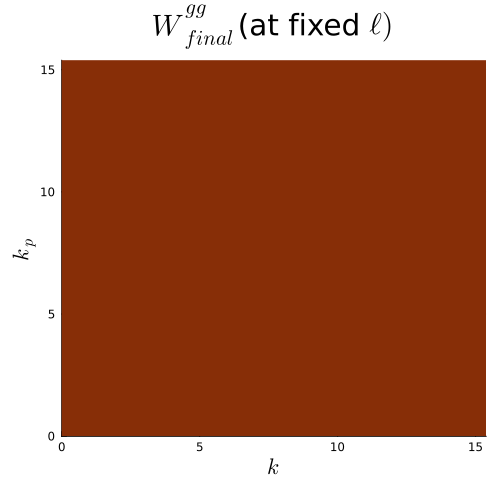

In [230]:
heatmap(k_grid, kp_grid, W_final_gal[50,:,:]./(maximum(W_final_gal[50,:,:])), size = (500,500), title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    c =:roma, xlabel=L"k",ylabel=L"k_p", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

In [231]:
savefig(joinpath(plot_subdir, "Sl_plots/k_grid_sorted_k_grid_sorted.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_30_190005/plots/Sl_plots/k_grid_sorted_k_grid_sorted.png"

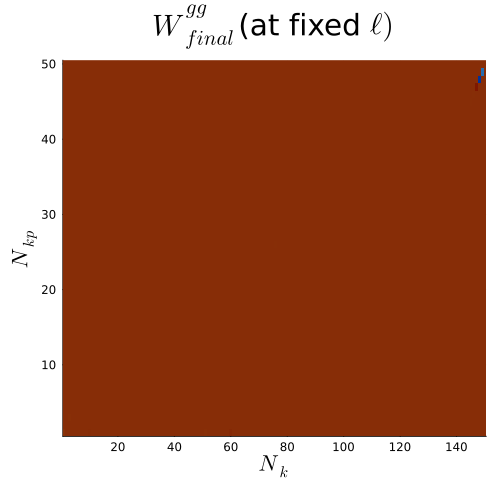

In [232]:
heatmap(1:Nk, 1:Nkp, W_final_gal[10,:,:]./(maximum(W_final_gal[10,:,:])), size = (500,500), title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    c =:roma , xlabel=L"N_k",ylabel=L"N_{kp}", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

In [233]:
savefig(joinpath(plot_subdir, "Sl_plots/Nk_Nkp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_30_190005/plots/Sl_plots/Nk_Nkp.png"

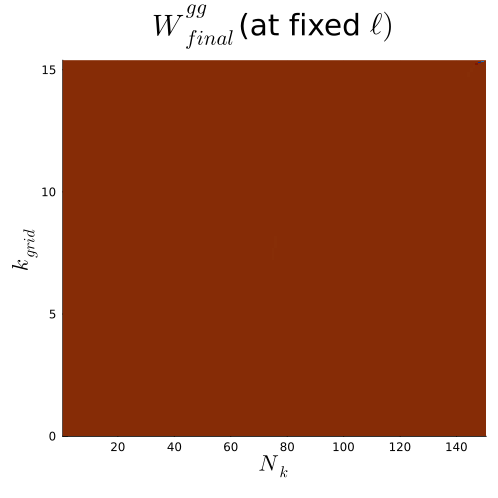

In [234]:
heatmap(1:Nk, kp_grid, W_final_gal[10,:,:]./(maximum(W_final_gal[10,:,:])), size = (500,500), title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    c =:roma , xlabel=L"N_k",ylabel=L"k_{grid}", legend=:none,
    yguidefontsize=15, xguidefontsize=15 , titlefontsize=20)

In [235]:
savefig(joinpath(plot_subdir, "Sl_plots/Nk_kp_grid_sorted.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_30_190005/plots/Sl_plots/Nk_kp_grid_sorted.png"

In [236]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z_pk = pk_dict["z"];
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x, y))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));
# plot(k, power_spectrum.(k, 1000.0, 1000.0), 
#      label="Linear P(k)", 
#      xscale=:log10, 
#      yscale=:log10, 
#      title=L"$P(k)$ at $z=0$", titlefontsize=20,
#      xlabel=L"$k \; (h/\mathrm{Mpc})$", 
#      ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
#      labelfontsize=15)
# plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
#       label="Non-linear P(k)", 
#       xscale=:log10, 
#       yscale=:log10,
#       size=(800,600),
#       legendfontsize=10)

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [237]:
Pk_grid = power_spectrum.(k_grid, kmin, kmax)
w_k = Blast.get_clencurt_weights(kmin, kmax, Nk)
weight_gal = w_k .* k_grid.^2 .* Pk_grid 
;

In [238]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), ℓ)
pref_ss = reduce(vcat, pref_ss);

In [239]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal))
println("pref_gg -> ", size(pref_gg), "\npref_ss -> ", size(pref_ss), "\npref_gs -> ", size(pref_gs))

SIZES
weight_gal -> (150,)
W_final_gal -> (100, 150, 50)
pref_gg -> (100,)
pref_ss -> (100,)
pref_gs -> (100,)


In [240]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(ℓ))
# k1 and k2 are alredy inside the W_tilde (for now, equal to k. and also k1 = k2)
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
#@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp] * kp_grid[kp] * kp_grid[kpp]
println("Size of S_l (kp, kpp) (gal-gal):  ", size(S_lkk_gg))
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
;

Size of S_l (kp, kpp) (gal-gal):  (50, 50, 100)


In [241]:
i = Nkp
j = Nkpp
k1 = kp_grid[i]
k2 = kpp_grid[j];

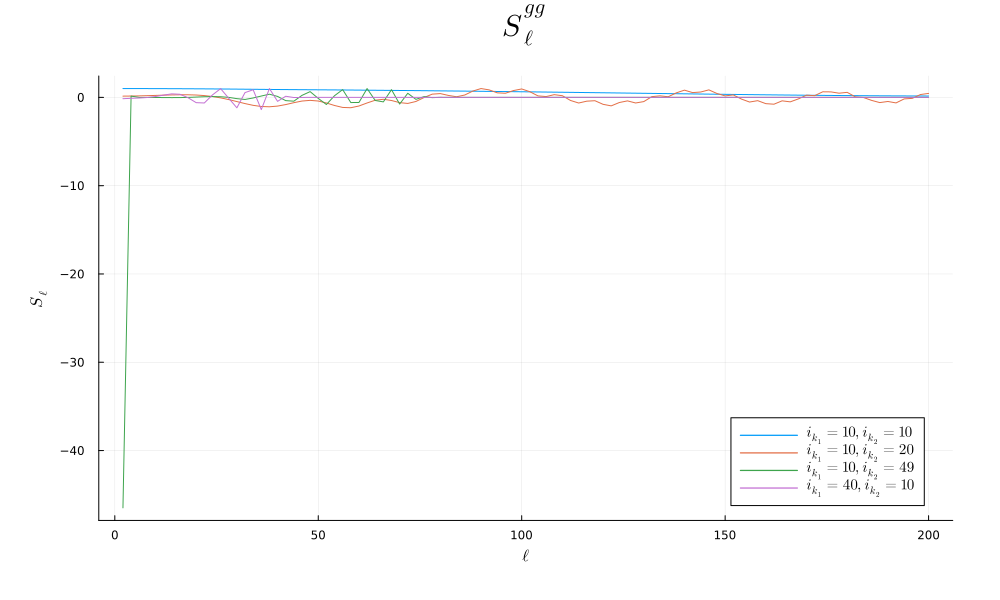

In [242]:
# plot
i = 10
j = 10
plot(ℓ, S_lkk_gg[10,10,:]/maximum(S_lkk_gg[10,10,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)")
i = 10
j = 20
plot!(ℓ, S_lkk_gg[10,20,:]/maximum(S_lkk_gg[10,20,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)")
i = 10
j = 49
plot!(ℓ, S_lkk_gg[10,49,:]/maximum(S_lkk_gg[10,49,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)")
i = 40
j = 10
plot!(ℓ, S_lkk_gg[40,10,:]/maximum(S_lkk_gg[40,10,:]), label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)")

plot!(label="Beyond BLAST", 
    xlabel=L"\ell", ylabel=L"S_\ell", 
    title=L"S_\ell^{gg}",
    size=(1000, 600), titlefontsize=20, 
    legendfontsize=10, margin = 10mm)

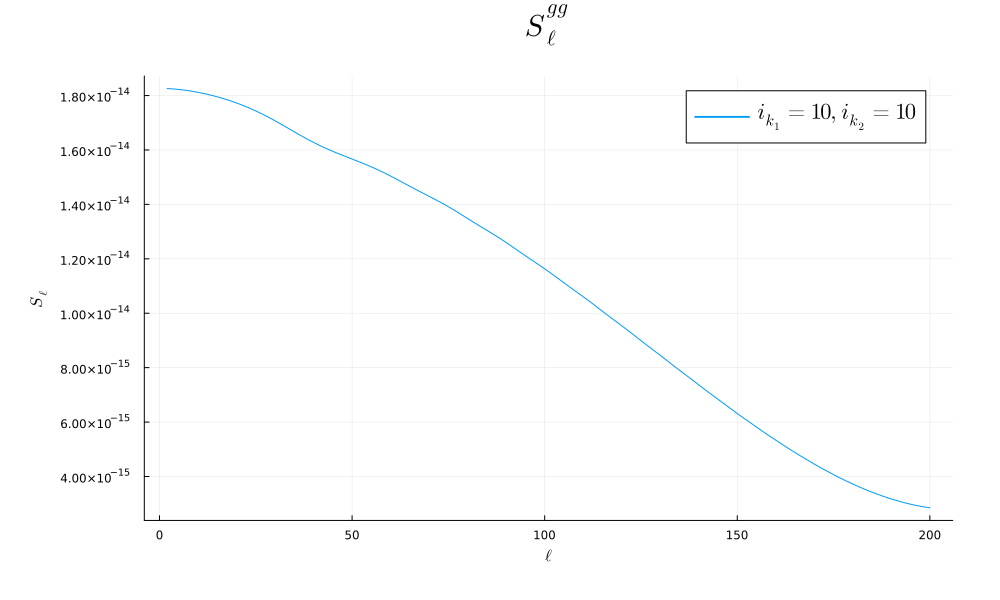

In [243]:
# plot
i = 10
j = 10
plot(ℓ, S_lkk_gg[10,10,:], label = L"i_{k_1} = %$(i), i_{k_2} = %$(j)")
i = 10
j = 20

plot!(label="Beyond BLAST", 
    xlabel=L"\ell", ylabel=L"S_\ell", 
    title=L"S_\ell^{gg}",
    size=(1000, 600), titlefontsize=20, 
    legendfontsize=15, margin = 10mm)

In [244]:
# # plot
# i = 1
# j = 1
# p1 =  plot(ℓ, k1 * k2 * S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg} k_1 k_2")
# p2 =  plot(ℓ, S_lkk_gg[i,j,:], label="Beyond BLAST", xlabel=L"\ell", ylabel=L"S_\ell", title=L"S_\ell(k_1, k_2)^{gg}")

# plot(p1, p2, layout = (1, 2), size=(2000, 600), titlefontsize=20, legendfontsize=10, margin = 10mm)

In [245]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_and_k1k2.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_30_190005/plots/Sl_plots/S_l_plot_gg_and_k1k2.png"

In [246]:
println("k")
ka = Nk
println(k_grid[ka])
kb = Nk - 5
println(k_grid[kb])
kc = Nk - 10
println(k_grid[kc])
kd = Nk - 30
println(k_grid[kd])
ke = Nk - Nk + 3
println(k_grid[ke])
##################
println("kp")
kpa = Nkp
println(k_grid[kpa])
kpb = Nkp - 5
println(k_grid[kpb])
kpc = Nkp - 10
println(k_grid[kpc])
kpd = Nkp - 20
println(k_grid[kpd])
kpe = Nkp - Nkp + 3
println(k_grid[kpe])
;

k
15.38461523076923
15.341910109509577
15.214268467735668
13.896428204333077
0.0071953052911464255
kp
3.7531672923741524
3.0798147933335205
2.457679688338337
1.394048088425028
0.0071953052911464255


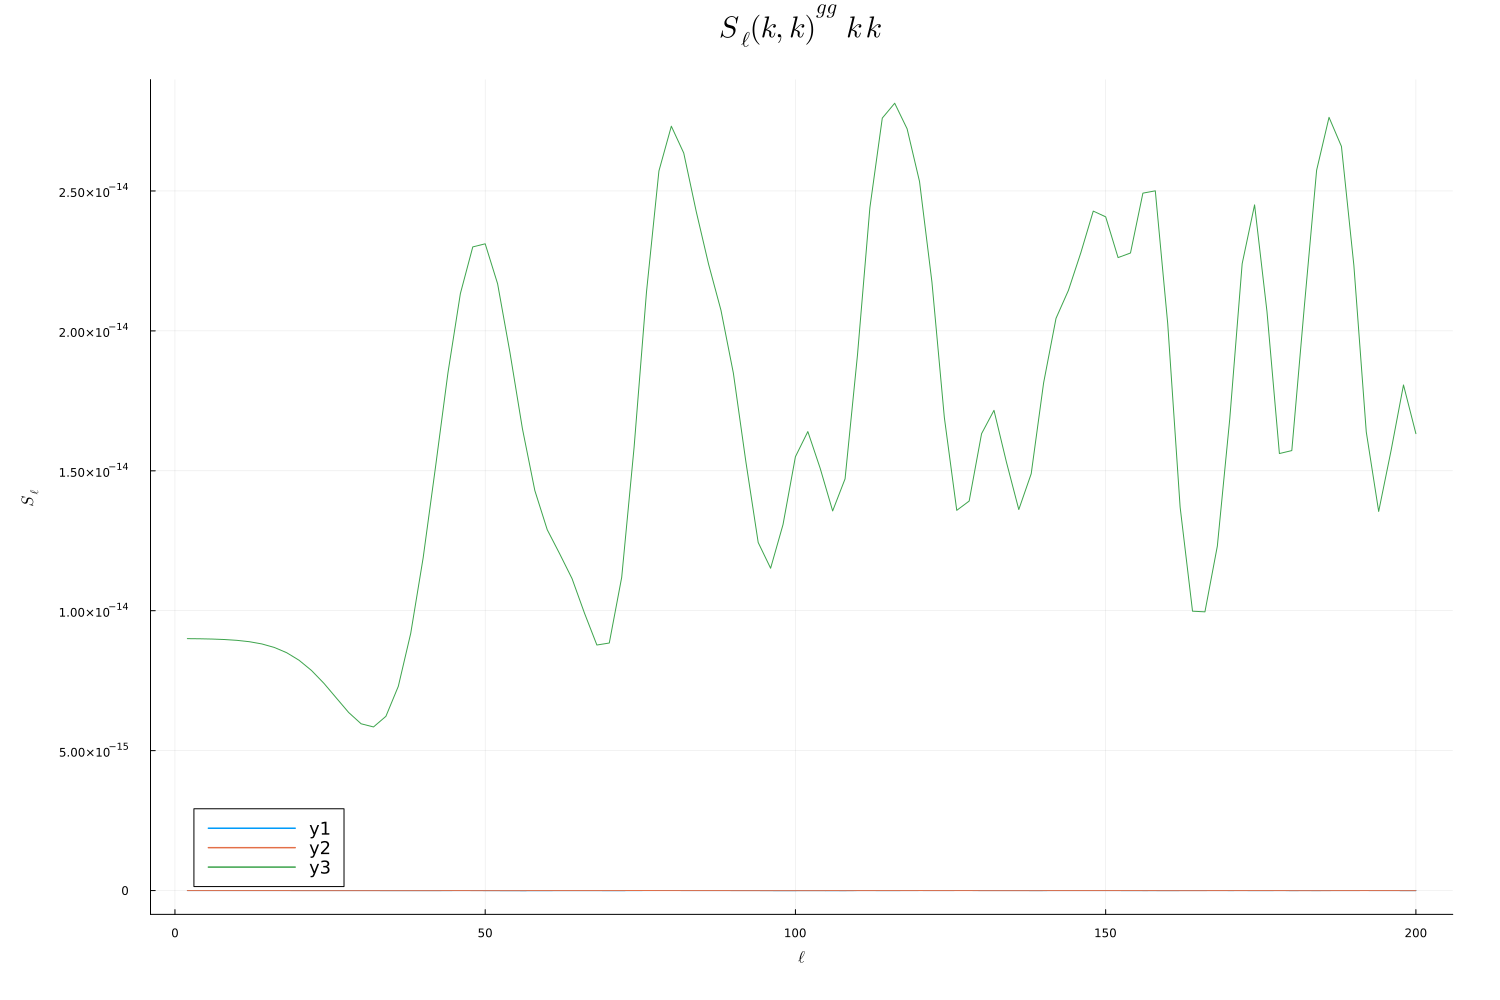

In [247]:
p = 
plot(ℓ, S_lkk_gg[2,20,:],
    #label="k = 0.000357 h/Mpc"
    )
plot!(p, ℓ, S_lkk_gg[10,22,:],
#     #label="k = 0.004562 h/Mpc"
     )
plot!(p, ℓ, S_lkk_gg[5,5,:],
#      #label="k = 0.017175 h/Mpc"
      )
# plot!(p, ℓ, S_lkk_gg[30,30,:],
#     #label="k = 0.151276 h/Mpc"
#     )
# plot!(p, ℓ, S_lkk_gg[10,10,:],
#     #label="k = 15.3846 h/Mpc"
#     )
plot!(p,
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    size=(1500, 1000),
    title=L"S_\ell(k, k)^{gg} \ k\,k",
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm)
plot!(p, legendposition=:bottomleft)

In [248]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_different_ks.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_30_190005/plots/Sl_plots/S_l_plot_gg_different_ks.png"

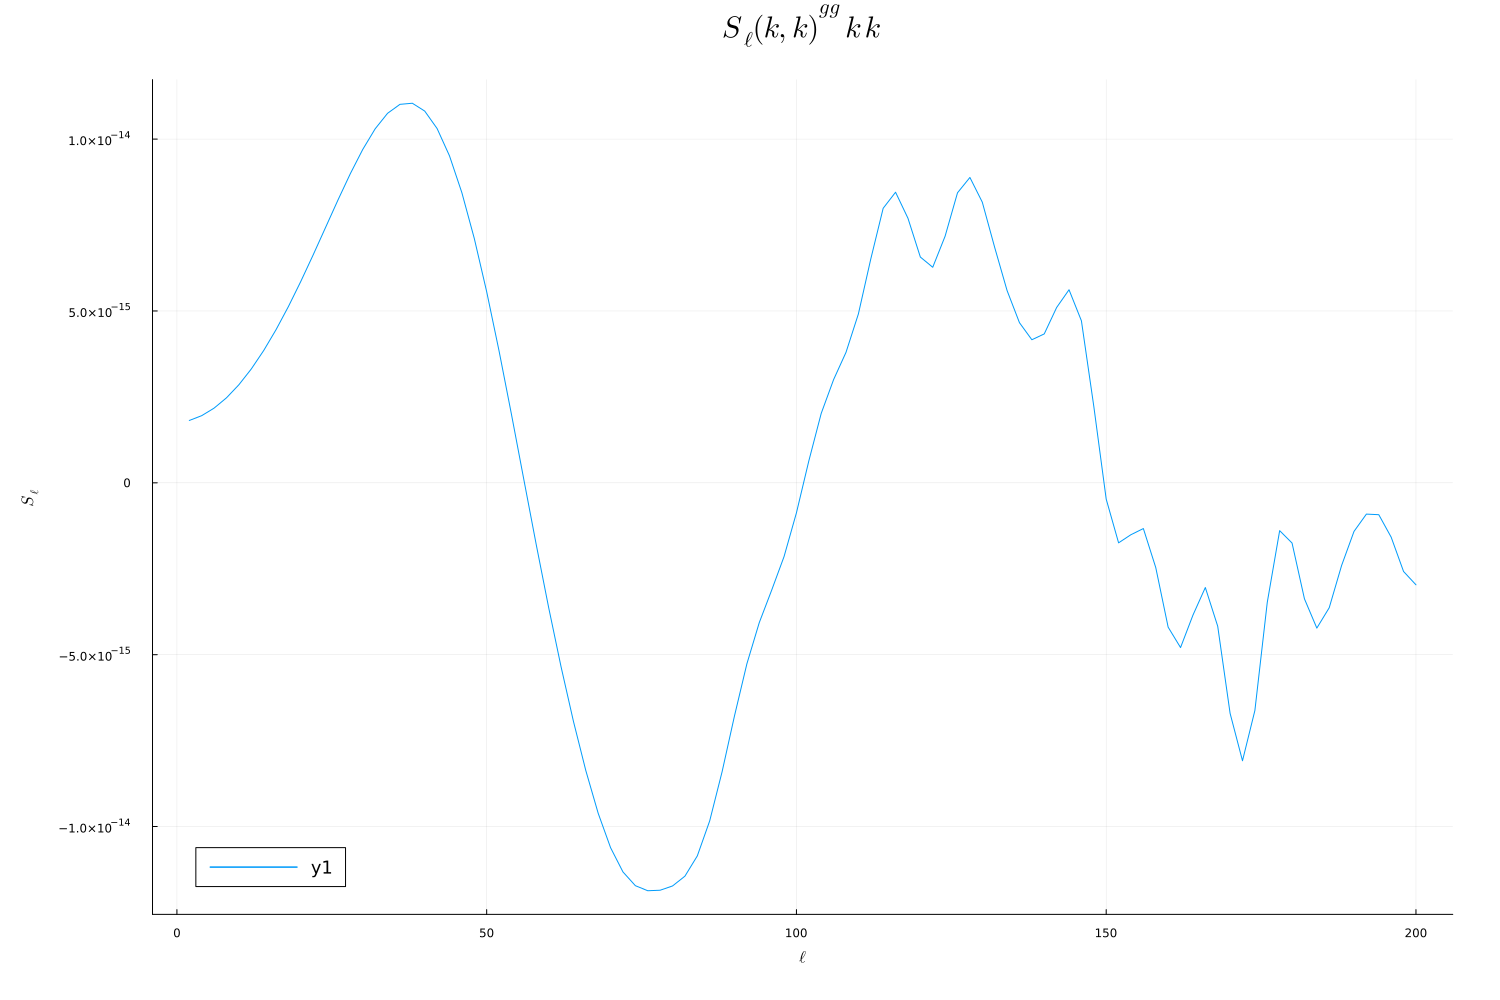

In [249]:
i = 1
j = 1

p = plot(ℓ, S_lkk_gg[5,9,:],
    #label="k1 = 0.000357 h/Mpc e k2 = 0.004562 h/Mpc",
    xlabel=L"\ell",
    ylabel=L"S_\ell",
    title=L"S_\ell(k, k)^{gg} \, k\,k")
# plot!(p, ℓ, S_lkk_gg[50,70,:],
#     label="k1 = 0.004562 h/Mpc e k2 = 0.017175 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[30,50,:],
#     label="k1 = 0.017175 h/Mpc e k2 = 0.151276 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[10,30,:],
#     label="k1 = 0.000357 h/Mpc e k2 = 0.151276 h/Mpc")
# plot!(p, ℓ, S_lkk_gg[i,j,:],
#     label="k1 = 0.000357 h/Mpc e k2 = 15.3846 h/Mpc")
plot!(p,
    size=(1500, 1000),
    titlefontsize=20,
    legendfontsize=12,
    margin=10mm,
    legendposition=:bottomleft)

In [250]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_gg_different_k_and_ks.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_30_190005/plots/Sl_plots/S_l_plot_gg_different_k_and_ks.png"

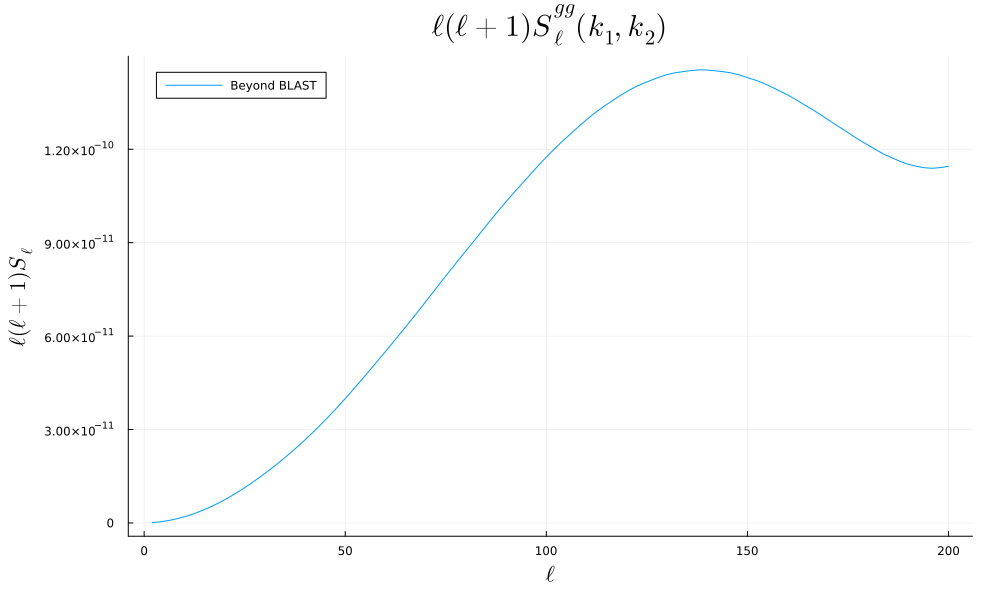

In [251]:
plot(
    ℓ,
    S_lkk_gg[10, 10, :] .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}(k_1,k_2)",
    markersize=4,
    size = (1000, 600),
    titlefontsize=20,
    labelfontsize=15,
    margin = 5mm
)

In [252]:
println(size(S_lkk_gg))

(50, 50, 100)


Size of S_lkk_gg: (50, 50, 100)
Size of diagS: (100,)
Size of k_grid: (150,)


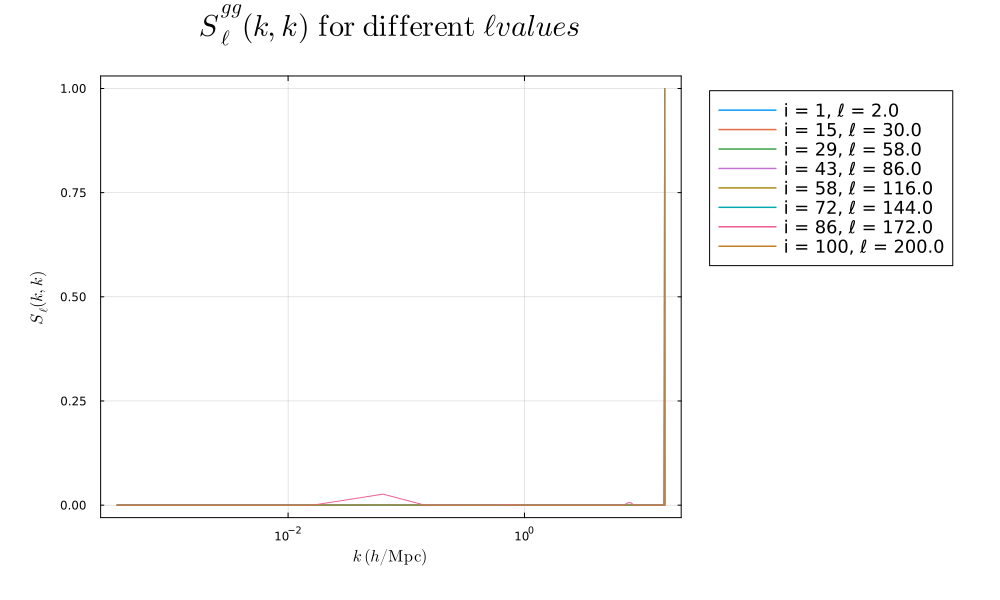

In [253]:
# S_lkk ha dimensioni (k1, k2, ℓ) = [Nk,Nkp,100]
# k_grid deve avere lunghezza Nk
# ℓ deve avere lunghezza 100

diagS = [diag(@view S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]
println("Size of S_lkk_gg: ", size(S_lkk_gg))
println("Size of diagS: ", size(diagS))
println("Size of k_grid: ", size(k_grid))
nshow = 8
idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

p = plot(
    xscale = :log10,
    xlabel = L"k \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell(k,k)",
    title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell values",
    legend = :topright,
    framestyle = :box,
    grid = true,
    lw = 2,
    size = (1000, 600),
    titlefontsize = 20,
    legendfontsize = 12,
    margin = 10mm,
    legendposition = :outertopright
)

for i in idx
    plot!(p, kp_grid, diagS[i]/maximum(diagS[i]), label = "i = $i, ℓ = $(round(ℓ[i], digits=2))")
end

display(p)

In [254]:
savefig(joinpath(plot_subdir, "Sl_plots/S_l_plot_ll+1.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_06_30_190005/plots/Sl_plots/S_l_plot_ll+1.png"

In [255]:
# heatmap(ℓ, log10.(sort(k_grid)), S_lkk_gg[1,:,:], ylabel=L"\log_{10}(k \; (h/\mathrm{Mpc}))", xlabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [256]:
# heatmap(log10.(sort(k_grid)), log10.(sort(k_grid)), S_lkk_gg[:,:,1], ylabel=L"\log_{10}(k \; (h/\mathrm{Mpc}))", xlabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [257]:
# #heatmap(k_grid, ℓ, S_lkk_gg[:,1,:], xlabel=L"k \; (h/\mathrm{Mpc})", ylabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))
# #if i want it into log
# heatmap(sort(k_grid), ℓ, S_lkk_gg[:,1,:], xlabel=L"\log_{10}(\mathrm{k} \; (h/\mathrm{Mpc}))", ylabel=L"\ell", title=L"S_{lkk}^{gg}", margin = 10mm, size =(1000, 600))

In [258]:
# # S_lkk ha dimensioni (k1, k2, ℓ) = [96,96,100]
# # k_grid deve avere lunghezza 96
# # ℓ deve avere lunghezza 100

# diagS = [diag(@view S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]
# print(size(diagS))
# nshow = 8
# idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

# p = plot(
#     xscale = :log10,
#     xlabel = L"k \; (h/\mathrm{Mpc})",
#     ylabel = L"S_\ell(k,k)",
#     title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell values",
#     legend = :topright,
#     framestyle = :box,
#     grid = true,
#     lw = 2,
#     size = (1000, 600),
#     titlefontsize = 20,
#     legendfontsize = 12,
#     margin = 10mm,
#     legendposition = :outertopright
# )

# for i in idx
#     plot!(p, k_grid, diagS[i], label = "ℓ=$(i)")

# end

# display(p)

---

#### Are the two methods to compute $W$ the same?

In [ ]:
# W_tilde_slow = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_slow.npy");
# W_tilde_fast = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_fast.npy");
# rel_difference = maximum(abs.(W_tilde_fast .- W_tilde_slow)) / maximum(abs.(W_tilde_fast))
# println(abs.(minimum(W_tilde_fast)))
# println(abs.(minimum(W_tilde_slow)))
# println(abs.(maximum(W_tilde_fast)))
# println(abs.(maximum(W_tilde_slow)))

LoadError: SystemError: opening file "/Users/anvi/Desktop/cosmo/notebooks/out/W_tilde_slow.npy": No such file or directory